# 07. 가설 설정·검정

| 항목 | 내용 |
|---|---|
| 목적 | 1~6단계 결과를 바탕으로 가설을 **귀무가설·대립가설·검정 방법·판정** 형태로 정식화하고, 다음 분석 단계와 제출물에 쓸 **핵심 메시지**를 정리한다 |
| 입력 | `data/processed/` — 분석 테이블(01), EDA 효과(03), 피해 예측(05), 지원금 배분(06) 산출물 |
| 출력 | `references/hypotheses.csv` (가설 정리표, git 관리) |
| 브랜치 | `ana-hypo` |

**진행 순서**
1. 환경 설정
2. 가설 1 — 같은 피해액, 다른 타격
3. 가설 2 — 동일 지원은 효과적이지 않다
4. 가설 3 — 기상 유형에 따라 업종 피해가 다르다
5. 분석에서 새로 도출된 가설 (H4~H6)
6. 가설 종합표
7. 핵심 메시지와 한계

## 1. 환경 설정

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import kendalltau, spearmanr, wilcoxon

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.3f}'.format)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = ROOT / 'data' / 'processed'
REF = ROOT / 'references'
load = lambda name: pd.read_parquet(PROC / f'{name}.parquet')

INK, INK2, GRID, SURFACE = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
REGION_COLOR = {'강남구': '#2a78d6', '춘천시': '#eb6834'}
plt.rcParams.update({
    'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.dpi': 110,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK, 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
KEYS = ['region', 'industry_group']
summ = load('damage_unit_summary')
units = summ[(summ['industry_group'] != '대형유통') & (summ['annual_loss'] > 0)].reset_index(drop=True)
units['R'] = units['sales_per_store_monthly'] * 12
units['L'] = units['annual_loss_per_store']
units['rate'] = units['L'] / units['R'] * 100
print(f'가설 1·2 분석 단위: 소상공인 업종 {len(units)}개 (대형유통 제외, 연간 예상 손실 > 0)')

가설 1·2 분석 단위: 소상공인 업종 28개 (대형유통 제외, 연간 예상 손실 > 0)


## 2. 가설 1 — 같은 피해액, 다른 타격

> **사용자 가설**: A·B·C 업체가 각각 100만원 피해를 입어도, 월매출이 100만·500만·1,000만원으로 다르면 실제 손실(타격)은 같지 않다.

| 구분 | 내용 |
|---|---|
| **H1₀ (귀무)** | 업체가 느끼는 타격은 피해 **금액**으로 충분히 설명된다 — 피해액 순위와 피해율(피해 ÷ 매출) 순위가 같다 (ρ = 1) |
| **H1₁ (대립)** | 피해액 순위와 피해율 순위는 다르다 — 같은 금액이라도 매출 규모에 따라 타격이 다르다 (ρ < 1) |
| 검정 | ① 점포당 연간 손실액과 피해율의 순위 상관(스피어만·켄달) + **부트스트랩 95% 신뢰구간** ② 손실액이 비슷한 업종끼리 피해율 차이 |
| 데이터 | 05단계 연간 예상 손실 (소상공인 업종 28개 단위) |

In [2]:
rho, _ = spearmanr(units['L'], units['rate'])
tau, _ = kendalltau(units['L'], units['rate'])
rng = np.random.default_rng(42)
boot = []
for _ in range(5000):
    idx = rng.integers(0, len(units), len(units))
    boot.append(spearmanr(units['L'].values[idx], units['rate'].values[idx])[0])
lo, hi = np.nanpercentile(boot, [2.5, 97.5])
print(f'점포당 연간 손실액 vs 피해율: 스피어만 ρ = {rho:.2f} (95% CI {lo:.2f} ~ {hi:.2f}), 켄달 τ = {tau:.2f}')
print(f'→ 신뢰구간 상한 {hi:.2f} < 1 이므로 "두 순위가 같다"(H1₀)는 기각된다')

# 순위가 뒤집히는 쌍의 비율: 손실액은 더 큰데 피해율은 더 낮은 쌍
L, r = units['L'].values, units['rate'].values
pairs = [(i, j) for i in range(len(units)) for j in range(i + 1, len(units))]
disc = np.mean([(L[i] - L[j]) * (r[i] - r[j]) < 0 for i, j in pairs])
print(f'업종 쌍 {len(pairs)}개 중 "손실액이 큰 쪽이 오히려 피해율은 낮은" 쌍: {disc:.1%}')

점포당 연간 손실액 vs 피해율: 스피어만 ρ = 0.55 (95% CI 0.21 ~ 0.78), 켄달 τ = 0.39
→ 신뢰구간 상한 0.78 < 1 이므로 "두 순위가 같다"(H1₀)는 기각된다
업종 쌍 378개 중 "손실액이 큰 쪽이 오히려 피해율은 낮은" 쌍: 30.4%


In [3]:
band = units[(units['L'] >= 400e4) & (units['L'] <= 700e4)].sort_values('R')
view = band.assign(점포당연간손실_만원=band['L'] / 1e4, 점포당연매출_만원=band['R'] / 1e4)[
    ['region', 'industry_group', '점포당연간손실_만원', '점포당연매출_만원', 'rate']].rename(columns={'rate': '피해율(%)'})
print(f"손실액이 비슷한(연 400만~700만원) 업종 {len(band)}개: 피해율 최대 ÷ 최소 = {band['rate'].max() / band['rate'].min():.1f}배")
view.round(2)

손실액이 비슷한(연 400만~700만원) 업종 4개: 피해율 최대 ÷ 최소 = 4.0배


,region,industry_group,점포당연간손실_만원,점포당연매출_만원,피해율(%)
21,춘천시,여가·오락,518.470,"23,794.060",2.180
6,강남구,식료품소매,410.580,"28,513.760",1.440
23,춘천시,의료·보건,566.860,"68,551.870",0.830
3,강남구,기타소매,592.270,"108,088.560",0.550


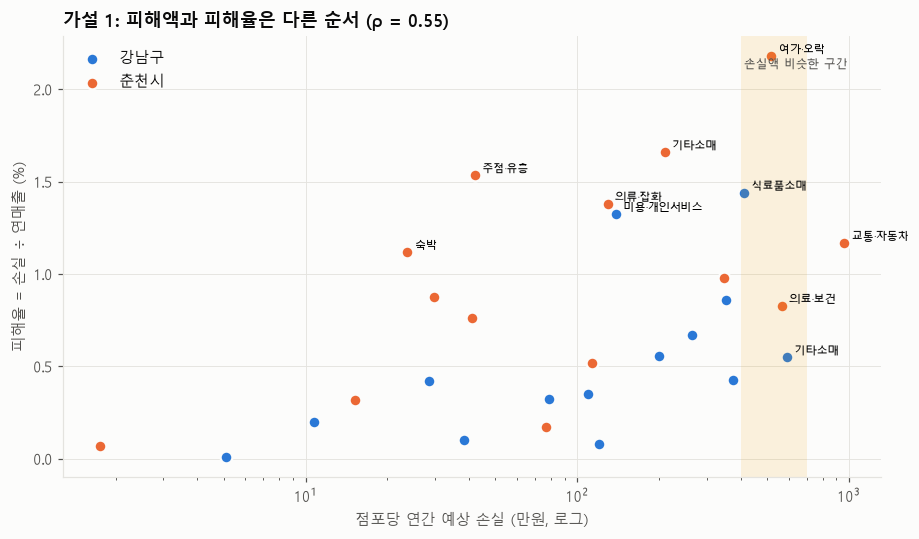

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for reg in ['강남구', '춘천시']:
    d = units[units['region'] == reg]
    ax.scatter(d['L'] / 1e4, d['rate'], s=60, color=REGION_COLOR[reg], edgecolor=SURFACE, linewidth=1.5, label=reg)
    for _, row in d.iterrows():
        if row['rate'] > 1.0 or row['L'] > 400e4:
            ax.annotate(row['industry_group'], (row['L'] / 1e4, row['rate']), textcoords='offset points', xytext=(5, 2), fontsize=7.5)
ax.axvspan(400, 700, color='#eda100', alpha=0.12, lw=0)
ax.text(410, units['rate'].max() * 0.97, '손실액 비슷한 구간', fontsize=8, color=INK2)
ax.set_xscale('log')
ax.set_xlabel('점포당 연간 예상 손실 (만원, 로그)'); ax.set_ylabel('피해율 = 손실 ÷ 연매출 (%)')
ax.set_title(f'가설 1: 피해액과 피해율은 다른 순서 (ρ = {rho:.2f})')
ax.legend()
fig.tight_layout()

**판정 — H1 지지 (귀무가설 기각)**
- 점포당 손실액과 피해율의 순위 상관은 ρ = 0.55이고, 95% 신뢰구간(0.21~0.78)이 1을 포함하지 않는다. **피해 금액만으로는 업체의 타격 순서를 설명할 수 없다.**
- 업종 쌍 378개 중 30%는 "손실액은 더 큰데 피해율은 더 낮은" 역전 관계다.
- 손실액이 비슷한(연 400만~700만원) 4개 업종의 피해율은 0.55% ~ 2.18%로 **4.0배** 차이 난다. 연매출 2.4억원인 춘천 여가·오락 점포와 10.8억원인 강남 기타소매 점포가 비슷한 금액을 잃어도 타격은 4배 다르다 — 사용자 예시(월매출 100만·500만·1,000만원)의 구조 그대로다.

## 3. 가설 2 — 동일 지원은 효과적이지 않다

> **사용자 가설**: 피해 금액이 같은 업체들에게 동일한 지원을 하는 것이 효과적일까?

| 구분 | 내용 |
|---|---|
| **H2₀ (귀무)** | 균등 지원(모든 점포 같은 금액)과 피해율 기준 최적 배분의 성과는 같다 |
| **H2₁ (대립)** | 피해율 기준 최적 배분이 균등 지원보다 ① 가장 힘든 업체의 잔여 피해율을 더 낮추고 ② 낭비가 적다 |
| 검정 | 피해 추정에 오차(±30%)를 넣은 500회 시뮬레이션에서 두 방식의 **짝지은 차이**를 윌콕슨 부호순위 검정 |
| 데이터 | 05단계 연간 예상 손실, 06단계 배분 방식 (예산 = 연간 손실의 25%) |

In [5]:
def equal(u, B):
    return np.full(len(u), B / u['n_stores'].sum())

def optimal(u, B):
    # 피해율 상한 c를 이분 탐색으로 찾는 '물 채우기' 해 (06단계 선형계획 해와 동일)
    lo, hi = 0.0, (u['L'] / u['R']).max()
    for _ in range(100):
        c = (lo + hi) / 2
        lo, hi = (c, hi) if (u['n_stores'] * np.maximum(0, u['L'] - c * u['R'])).sum() > B else (lo, c)
    return np.maximum(0, u['L'] - hi * u['R']).values

def score(u, s):
    covered = np.minimum(s, u['L'])
    resid = (u['L'] - covered) / u['R'] * 100
    return resid.max(), (u['n_stores'] * np.maximum(s - u['L'], 0)).sum() / 1e8

rng = np.random.default_rng(42)
sim = []
for d in range(500):
    noisy = units.copy()
    noisy['L'] = units['L'] * rng.lognormal(0, 0.3, len(units))
    B = 0.25 * (noisy['n_stores'] * noisy['L']).sum()
    for name, f in [('균등', equal), ('최적', optimal)]:
        mx, waste = score(units, f(noisy, B))          # 배분은 '추정 손실'로, 평가는 '실제 손실'로
        sim.append({'draw': d, '방식': name, '최대 잔여 피해율(%)': mx, '낭비(억원)': waste})
sim = pd.DataFrame(sim)
rows = []
for col in ['최대 잔여 피해율(%)', '낭비(억원)']:
    w = sim.pivot(index='draw', columns='방식', values=col)
    diff = w['최적'] - w['균등']
    stat, p = wilcoxon(w['최적'], w['균등'], alternative='less')
    rows.append({'지표': col, '균등 중앙값': w['균등'].median(), '최적 중앙값': w['최적'].median(),
                 '차이 중앙값(최적−균등)': diff.median(), '최적이 더 나은 비율': (diff < 0).mean(), '윌콕슨 p (단측)': p})
h2 = pd.DataFrame(rows)
h2

,지표,균등 중앙값,최적 중앙값,차이 중앙값(최적−균등),최적이 더 나은 비율,윌콕슨 p (단측)
0,최대 잔여 피해율(%),1.956,1.101,-0.850,0.998,0.000
1,낭비(억원),30.809,2.770,-26.136,0.968,0.000


In [6]:
alloc = load('support_allocation')
per = alloc.groupby('방식').apply(lambda g: pd.Series({
    '최대 잔여 피해율(%)': g['지원 후 피해율(%)'].max(),
    '피해율 상위 5개 업종 평균 잔여(%)': g.nlargest(5, 'rate')['지원 후 피해율(%)'].mean()}))
print('06단계 기본 배분안 (예산 = 손실의 25%, 추정 오차 없음)')
per.round(2)

06단계 기본 배분안 (예산 = 손실의 25%, 추정 오차 없음)


,최대 잔여 피해율(%),피해율 상위 5개 업종 평균 잔여(%)
방식,,
A 균등 지원,1.960,1.060
B 피해액 비례,1.630,1.230
C 피해액 큰 순,2.180,1.640
D 피해율 높은 순,0.830,0.000
E 최적화(피해율 상한),0.530,0.530


**판정 — H2 지지 (귀무가설 기각)**
- 피해 추정 오차(±30%)를 넣은 500회 시뮬레이션에서, 피해율 기준 최적 배분은 균등 지원보다
  - 가장 힘든 업체의 잔여 피해율이 **1.96% → 1.10%** (중앙값)로 낮고, 99.8%의 경우에 더 낫다 (윌콕슨 p ≈ 0)
  - 낭비(손실보다 많이 준 금액)가 **약 31억원 → 약 3억원**으로 적다 (96.8%의 경우에 더 적음)
- 오차가 없는 기본 배분안에서도 균등 지원은 피해율 상위 5개 업종에 평균 1.06%의 피해율을 남기지만, 최적 배분은 모든 업종을 0.53% 이하로 낮춘다.
- → **같은 예산이라도 '모두에게 같은 금액'은 낭비가 생기고 가장 타격이 큰 업체를 구제하지 못한다.** 매출 규모를 반영한 피해율 기준 배분이 더 효과적이다.

## 4. 가설 3 — 기상 유형에 따라 업종 피해가 다르다

> **사용자 가설**: 폭염이면 빙과류는 괜찮지만 떡볶이처럼 뜨거운 음식은 힘들고, 폭설이면 반대가 되지 않을까? (예시 — 업종은 데이터로 확인)

| 구분 | 내용 |
|---|---|
| **H3₀ (귀무)** | 기상 효과는 업종과 무관하게 같다 — 모든 업종의 강한 비 효과·폭염 효과가 같다 (업종 × 기상 상호작용 = 0) |
| **H3₁ (대립)** | 기상 효과의 크기·방향이 업종마다 다르고, 같은 업종도 기상 유형에 따라 반응이 다르다 |
| 검정 | ① 지역별 패널 회귀(주 고정효과)에서 **업종 × 강한 비**, **업종 × 폭염** 상호작용이 모두 0인지 결합 Wald 검정 (날짜 군집 표준오차) ② 업종의 강한 비 효과 순위와 폭염 효과 순위의 상관 ③ 05단계 모델에서 반응 방향이 바뀌는 업종 수 |
| 데이터 | 01단계 분석 테이블(일 × 지역 × 업종), 03단계 EDA 효과, 05단계 피해 |

In [7]:
daily = load('analysis_daily_group')
daily['log_amt'] = np.log1p(daily['amount'])
daily['week'] = daily['date'].dt.isocalendar().week.astype(int)
daily['rain_heavy'] = (daily['rain_sum'] >= 30).astype(int)
daily['rain_mid'] = ((daily['rain_sum'] >= 5) & (daily['rain_sum'] < 30)).astype(int)
daily['heat_33'] = (daily['feels_like_max'] >= 33).astype(int)
daily['snow'] = daily['snow_day'].astype(int)
for c in ['is_holiday', 'is_payday_week']:
    daily[c] = daily[c].astype(int)

tests = []
for reg in ['강남구', '춘천시']:
    d = daily[daily['region'] == reg].copy()
    f = ('log_amt ~ C(industry_group) * (C(dow) + C(week) + is_holiday + is_payday_week)'
         ' + C(industry_group) * (rain_heavy + rain_mid + heat_33 + snow)')
    res = smf.ols(f, data=d).fit(cov_type='cluster', cov_kwds={'groups': d['date'].rank(method='dense').astype(int)})
    for term in ['rain_heavy', 'heat_33', 'snow']:
        names = [n for n in res.params.index if n.startswith('C(industry_group)[T.') and n.endswith(f':{term}')]
        Rm = np.zeros((len(names), len(res.params)))
        for k, n in enumerate(names):
            Rm[k, res.params.index.get_loc(n)] = 1
        wt = res.wald_test(Rm, scalar=True)
        tests.append({'region': reg, '기상': {'rain_heavy': '강한 비', 'heat_33': '폭염 33℃↑', 'snow': '눈'}[term],
                      '상호작용 수': len(names), 'Wald 통계량': float(wt.statistic), 'p값': float(wt.pvalue)})
h3_test = pd.DataFrame(tests)
h3_test

,region,기상,상호작용 수,Wald 통계량,p값
0,강남구,강한 비,14,48.973,0.000
1,강남구,폭염 33℃↑,14,54.775,0.000
2,강남구,눈,14,144.634,0.000
3,춘천시,강한 비,14,122.283,0.000
4,춘천시,폭염 33℃↑,14,30.894,0.006
5,춘천시,눈,14,106.913,0.000


In [8]:
eda = load('eda_effect_group')
w = eda.pivot_table(index=KEYS, columns='term', values='effect_pct')
rows = []
for reg in ['강남구', '춘천시']:
    x = w.loc[reg]
    r1, p1 = spearmanr(x['비 강(30mm~)'], x['폭염 33℃~'])
    rows.append({'region': reg, '비교': '강한 비 효과 vs 폭염 효과 (업종 순위)', 'ρ': r1, 'p값': p1})
    if '눈' in x:
        r2, p2 = spearmanr(x['비 강(30mm~)'], x['눈'], nan_policy='omit')
        rows.append({'region': reg, '비교': '강한 비 효과 vs 눈 효과', 'ρ': r2, 'p값': p2})
print('업종별 효과 순위가 기상 유형 간에 얼마나 같은가 (ρ ≈ 1 이면 같은 업종이 늘 취약)')
display(pd.DataFrame(rows))

dmg = load('damage_daily')
types = ['강한 비', '비', '폭염', '눈', '한파']
rate = dmg.groupby(KEYS + ['weather_type'], observed=True).apply(
    lambda g: (g['amount'].sum() / g['base_amount'].sum() - 1) * 100).unstack('weather_type').reindex(columns=types)
flip = ((rate <= -1).any(axis=1) & (rate >= 1).any(axis=1))
print(f'05단계 모델: 기상 유형에 따라 감소(≤ −1%)와 증가(≥ +1%)가 모두 나타나는 단위 {flip.sum()} / {len(rate)}')

업종별 효과 순위가 기상 유형 간에 얼마나 같은가 (ρ ≈ 1 이면 같은 업종이 늘 취약)


,region,비교,ρ,p값
0,강남구,강한 비 효과 vs 폭염 효과 (업종 순위),0.211,0.451
1,강남구,강한 비 효과 vs 눈 효과,-0.304,0.271
2,춘천시,강한 비 효과 vs 폭염 효과 (업종 순위),0.086,0.761
3,춘천시,강한 비 효과 vs 눈 효과,-0.043,0.879


05단계 모델: 기상 유형에 따라 감소(≤ −1%)와 증가(≥ +1%)가 모두 나타나는 단위 13 / 30


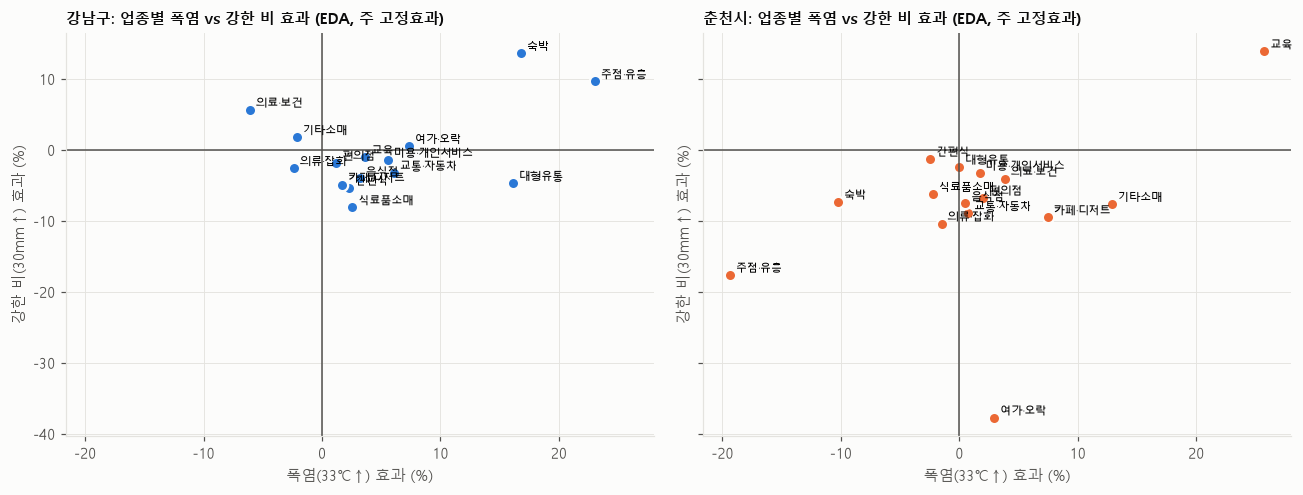

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, reg in zip(axes, ['강남구', '춘천시']):
    x = w.loc[reg]
    ax.scatter(x['폭염 33℃~'], x['비 강(30mm~)'], s=55, color=REGION_COLOR[reg], edgecolor=SURFACE, linewidth=1.5)
    for g, row in x.iterrows():
        ax.annotate(g, (row['폭염 33℃~'], row['비 강(30mm~)']), textcoords='offset points', xytext=(4, 2), fontsize=7.5)
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlabel('폭염(33℃↑) 효과 (%)'); ax.set_ylabel('강한 비(30mm↑) 효과 (%)')
    ax.set_title(f'{reg}: 업종별 폭염 vs 강한 비 효과 (EDA, 주 고정효과)', fontsize=10)
fig.tight_layout()

**판정 — H3 지지 (귀무가설 기각)**
- 두 지역 모두 **업종 × 강한 비**, **업종 × 폭염** 상호작용이 모두 0이라는 귀무가설이 기각된다 (p < 0.01). 기상 효과의 크기·방향은 업종마다 다르다.
- 업종의 강한 비 효과 순위와 폭염 효과 순위의 상관은 강남 0.21, 춘천 0.09로 거의 없다. **비에 약한 업종과 폭염에 영향받는 업종은 서로 다른 업종**이다. 눈 효과와의 상관은 오히려 음수(−0.04 ~ −0.30)다.
- 05단계 모델에서도 30개 단위 중 13개가 기상 유형에 따라 매출 감소와 증가가 모두 나타난다.
- 주의: '업종 × 눈' 검정도 유의하게 나왔지만 눈 온 날이 2~3일뿐이라, 날짜 군집 표준오차가 불안정해 **판정 근거로 쓰지 않는다.** 폭염 쪽은 휴가철 효과가 일부 섞였을 수 있다 (EDA는 주 고정효과로 통제).
- 사용자 예시(빙과 vs 떡볶이)는 카드 업종에 없지만, 같은 구조가 업종 단위에서 확인된다: 예) 커피전문점(폭염 ↑ / 비 ↓), 강남 대형유통(폭염 +16%), 춘천 숙박(비 ↓ / 폭염 ↑).

## 5. 분석에서 새로 도출된 가설 (H4~H6)
사용자 가설을 검증하는 과정에서 데이터가 보여준 추가 가설이다. 다음 분석(심화·보고서)에서 확인할 후보로 정리한다.

In [10]:
org = load('analysis_origin_group')
org = org[org['customer_origin'] != '미상']
tot = org.groupby(['date', 'region', 'customer_origin'], observed=True).agg(
    amount=('amount', 'sum'), dow=('dow', 'first'), is_holiday=('is_holiday', 'first'),
    is_payday_week=('is_payday_week', 'first'), rain_sum=('rain_sum', 'first'), feels=('feels_like_max', 'first')).reset_index()
tot['log_amt'] = np.log1p(tot['amount'])
tot['week'] = tot['date'].dt.isocalendar().week.astype(int)
tot['rain_heavy'] = (tot['rain_sum'] >= 30).astype(int)
tot['rain_mid'] = ((tot['rain_sum'] >= 5) & (tot['rain_sum'] < 30)).astype(int)
tot['heat_33'] = (tot['feels'] >= 33).astype(int)
tot['outsider'] = (tot['customer_origin'] == '외지').astype(int)
for c in ['is_holiday', 'is_payday_week']:
    tot[c] = tot[c].astype(int)
h4 = []
for reg in ['강남구', '춘천시']:
    d = tot[tot['region'] == reg]
    res = smf.ols('log_amt ~ outsider * (C(dow) + C(week) + is_holiday + is_payday_week + rain_mid + heat_33) + outsider * rain_heavy',
                  data=d).fit(cov_type='cluster', cov_kwds={'groups': d['date'].rank(method='dense').astype(int)})
    b = res.params['outsider:rain_heavy']; se = res.bse['outsider:rain_heavy']
    h4.append({'region': reg, '외지 − 현지 강한 비 효과 차이(%p, log×100)': b * 100,
               '95% CI 하한': (b - 1.96 * se) * 100, '95% CI 상한': (b + 1.96 * se) * 100, 'p값': res.pvalues['outsider:rain_heavy']})
print('H4: 강한 비 날 외지 고객 매출이 현지 고객보다 더 줄어드는가 (차이 < 0 이면 외지가 더 감소)')
pd.DataFrame(h4)

H4: 강한 비 날 외지 고객 매출이 현지 고객보다 더 줄어드는가 (차이 < 0 이면 외지가 더 감소)


,region,"외지 − 현지 강한 비 효과 차이(%p, log×100)",95% CI 하한,95% CI 상한,p값
0,강남구,0.018,-2.623,2.658,0.990
1,춘천시,-18.206,-27.268,-9.143,0.000


| 가설 | 내용 | 지금까지의 근거 | 다음에 확인할 것 |
|---|---|---|---|
| **H4 방문객 이탈 경로** | 춘천의 호우 피해는 외지(방문) 고객이 오지 않아서 생긴다 | 위 검정, EDA 5-4절 (외지 −20% vs 현지 −4%) | 행정동·관광지 단위, 다른 관광 도시로 확장 |
| **H5 영업시간 강수** | 하루 강수량보다 **업종의 영업시간에 내린 비**가 피해를 결정한다 | EDA 5-2절 (그 시간대 비만 매출 감소), 엔지니어링 AIC 비교 | 시간대 단위 모델, 예보 시간대별 지원 시점 |
| **H6 폭염 = 소비 이동** | 폭염은 지역 전체 매출을 줄이기보다 업종 사이로 소비를 옮긴다 (실내·냉방 업종 ↑) | EDA: 지역 전체 효과 ≈ 0, 강남 대형유통 +16% | 휴가철 효과를 더 엄밀히 분리한 다년 데이터로 재검증 |

## 6. 가설 종합표

In [11]:
H = pd.DataFrame([
    {'id': 'H1', '구분': '사용자', '가설': '같은 피해액이라도 업체 규모(매출)에 따라 실제 타격(피해율)이 다르다',
     '귀무가설': '피해액 순위 = 피해율 순위 (ρ = 1)', '검정': '스피어만 ρ + 부트스트랩 CI, 손실액 비슷한 업종 비교',
     '핵심 결과': f'ρ = {rho:.2f} (95% CI {lo:.2f}~{hi:.2f}), 순위 역전 쌍 {disc:.0%}, 비슷한 손실액에서 피해율 최대 {band["rate"].max() / band["rate"].min():.1f}배',
     '판정': '지지 (귀무 기각)', '단계': '02·03·05'},
    {'id': 'H2', '구분': '사용자', '가설': '동일 금액 지원은 효과적이지 않다 — 피해율 기준 배분이 더 낫다',
     '귀무가설': '균등 지원과 최적 배분의 성과가 같다', '검정': '추정 오차 500회 시뮬레이션, 윌콕슨 부호순위(단측)',
     '핵심 결과': (f"최대 잔여 피해율 균등 {h2.loc[0, '균등 중앙값']:.2f}% vs 최적 {h2.loc[0, '최적 중앙값']:.2f}%, "
                f"최적 우위 {h2.loc[0, '최적이 더 나은 비율']:.1%}, p = {h2.loc[0, '윌콕슨 p (단측)']:.1e}; "
                f"낭비 {h2.loc[1, '균등 중앙값']:.0f}억 vs {h2.loc[1, '최적 중앙값']:.0f}억"),
     '판정': '지지 (귀무 기각)', '단계': '06'},
    {'id': 'H3', '구분': '사용자', '가설': '기상 유형에 따라 업종별 피해의 방향·크기가 다르다',
     '귀무가설': '업종 × 기상 상호작용 = 0', '검정': '지역별 패널 회귀 결합 Wald 검정, 효과 순위 상관, 반응 방향 전환 수',
     '핵심 결과': '; '.join(f"{r['region']} {r['기상']} p = {r['p값']:.1e}" for _, r in h3_test.iterrows()) + f'; 방향 전환 단위 {flip.sum()}/{len(rate)}',
     '판정': '', '단계': '03·05·06'},
    {'id': 'H4', '구분': '도출', '가설': '춘천 호우 피해는 외지(방문) 고객 이탈에서 나온다',
     '귀무가설': '외지·현지 고객의 강한 비 효과가 같다', '검정': '고객 출신 × 강한 비 상호작용 (날짜 군집)',
     '핵심 결과': '; '.join(f"{r['region']} 차이 {r['외지 − 현지 강한 비 효과 차이(%p, log×100)']:+.1f}%p (p = {r['p값']:.3f})" for r in h4),
     '판정': '', '단계': '03·07'},
    {'id': 'H5', '구분': '도출', '가설': '업종 영업시간에 내린 비가 하루 강수량보다 피해를 잘 설명한다',
     '귀무가설': '영업시간 강수 노출과 일강수량의 설명력이 같다', '검정': 'AIC 비교 (04단계)',
     '핵심 결과': '두 지역 모두 영업시간 강수 노출의 AIC가 더 낮음 (춘천 −420 vs −366)', '판정': '잠정 지지', '단계': '03·04'},
    {'id': 'H6', '구분': '도출', '가설': '폭염은 피해라기보다 업종 간 소비 이동이다',
     '귀무가설': '폭염은 모든 업종 매출을 같은 방향으로 바꾼다', '검정': '지역 전체 효과 + 업종 × 폭염 상호작용 검정',
     '핵심 결과': '지역 전체 폭염 효과 유의하지 않음, 강남 대형유통 +16%', '판정': '', '단계': '03·07'},
])
h3_sig = (h3_test['p값'] < 0.05)
H.loc[H['id'] == 'H3', '판정'] = '지지 (귀무 기각)' if h3_sig.any() else '판단 보류'
h4_cc = [r for r in h4 if r['region'] == '춘천시'][0]
H.loc[H['id'] == 'H4', '판정'] = '지지 (춘천)' if (h4_cc['p값'] < 0.05 and h4_cc['외지 − 현지 강한 비 효과 차이(%p, log×100)'] < 0) else '판단 보류'
heat_p = h3_test[h3_test['기상'] == '폭염 33℃↑'].set_index('region')['p값']
H.loc[H['id'] == 'H6', '판정'] = '잠정 지지' if (heat_p < 0.05).any() else '판단 보류'
H.to_csv(REF / 'hypotheses.csv', index=False, encoding='utf-8-sig')
H[['id', '구분', '가설', '판정', '핵심 결과']]

,id,구분,가설,판정,핵심 결과
0,H1,사용자,같은 피해액이라도 업체 규모(매출)에 따라 실제 타격(피해율)이 다르다,지지 (귀무 기각),"ρ = 0.55 (95% CI 0.21~0.78), 순위 역전 쌍 30%, 비슷한 ..."
1,H2,사용자,동일 금액 지원은 효과적이지 않다 — 피해율 기준 배분이 더 낫다,지지 (귀무 기각),"최대 잔여 피해율 균등 1.96% vs 최적 1.10%, 최적 우위 99.8%, p..."
2,H3,사용자,기상 유형에 따라 업종별 피해의 방향·크기가 다르다,지지 (귀무 기각),강남구 강한 비 p = 9.1e-06; 강남구 폭염 33℃↑ p = 9.5e-07;...
3,H4,도출,춘천 호우 피해는 외지(방문) 고객 이탈에서 나온다,지지 (춘천),강남구 차이 +0.0%p (p = 0.990); 춘천시 차이 -18.2%p (p =...
4,H5,도출,업종 영업시간에 내린 비가 하루 강수량보다 피해를 잘 설명한다,잠정 지지,두 지역 모두 영업시간 강수 노출의 AIC가 더 낮음 (춘천 −420 vs −366)
5,H6,도출,폭염은 피해라기보다 업종 간 소비 이동이다,잠정 지지,"지역 전체 폭염 효과 유의하지 않음, 강남 대형유통 +16%"


**H4~H6 판정 근거**
- **H4**: 춘천은 강한 비 날 외지 고객 매출이 현지 고객보다 **18.2%p 더** 줄어든다 (95% CI −27.3 ~ −9.1%p, p < 0.001). 강남은 차이가 없다 (+0.0%p). → 춘천에서 지지.
- **H5**: 영업시간 강수 노출이 일강수량보다 설명력이 높다 (AIC). 시간대 단위 모델로 확정 필요 → 잠정 지지.
- **H6**: 지역 전체 폭염 효과는 유의하지 않은데 업종 × 폭염 상호작용은 유의하다 → 업종 사이 재배분과 맞는 결과. 휴가철 효과 분리가 남아 있어 잠정 지지.

## 7. 핵심 메시지와 한계

### 핵심 메시지 (제출용 초안)
1. **기후 피해는 '얼마를 잃었나'가 아니라 '매출의 몇 %를 잃었나'로 봐야 한다.** 비슷한 금액을 잃어도 업체 규모에 따라 타격은 4배까지 다르다 (H1).
2. **같은 예산이라도 '모두에게 같은 금액'은 비효율적이다.** 피해율 기준으로 배분하면 낭비가 약 90% 줄고 가장 힘든 업체의 피해율이 크게 낮아진다 (H2).
3. **기상 유형마다 피해 업종이 다르다.** 비에 약한 업종(춘천 여가·오락·숙박·의류·잡화 등)과 폭염에 영향받는 업종은 다르므로, 지원 대상 목록도 기상 유형별로 따로 둬야 한다 (H3).
4. **춘천 같은 방문객 상권은 비가 오면 외지 손님이 사라진다.** 외지 고객 매출이 현지보다 18%p 더 줄어, 방문 수요를 붙잡는 대응(예보 연동 쿠폰·관광 연계)이 필요하다 (H4).

### 정책 제안으로 이어지는 흐름
| 단계 | 근거 | 제안 |
|---|---|---|
| 누구를 | H1 — 피해율 | 소상공인 자격 확인 후 **피해율(피해 ÷ 매출)**로 우선순위 |
| 얼마나 | H2 — 최적 배분 | '모든 업체 피해율을 c% 이하로' 하는 상한 방식, 필요하면 최소 보전율 병행 |
| 어떤 기상에 | H3 — 유형별 차이 | 호우·폭염·한파·대설별 대상 업종 목록 분리 |
| 언제 | H4·H5 — 방문객·영업시간 | 예보 D-1 발동, 비가 올 시간대와 업종 영업시간을 맞춘 사전 지원 |

### 한계
| 한계 | 영향 | 보완 방향 |
|---|---|---|
| 기간 6개월·2개 지역 | 계절 일반화 제한, 눈·한파 표본 2~3일 | 다년·다지역 데이터 |
| 업종 '평균 점포' 가정 | 같은 업종 안의 규모 차이(실제 A·B·C)는 미반영 | 점포 단위 매출 데이터 확보 시 재검증 |
| 금액은 신한카드 기준 | 절대 금액은 실제보다 작음 (비율 비교는 유효) | 카드사 점유율 보정 |
| 폭염 효과의 계절 혼재 | 폭염 피해의 크기는 참고용 | 다년 데이터로 휴가철 분리 |
| 지원금이 손실을 1:1로 메운다는 가정 | 실제 정책 효과와 차이 가능 | 지원 수단별 효과(쿠폰·운영자금 등) 반영 |